In [493]:
##Projet Analyse Salma Ahizoune, Arbadji Massy

In [494]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

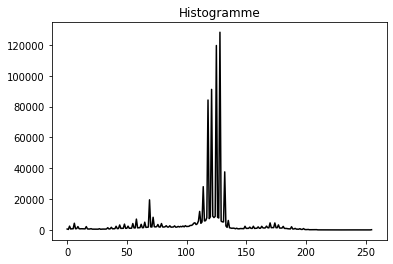

In [495]:
#on trace l'histogramme de l'image
image = cv2.imread('puzzle.jpg', cv2.IMREAD_GRAYSCALE)
histogramme = cv2.calcHist([image], [0], None, [256], [0, 256])

plt.plot(histogramme, color='black')
plt.title("Histogramme")
plt.show()

Nombre de pièces détectées : 4


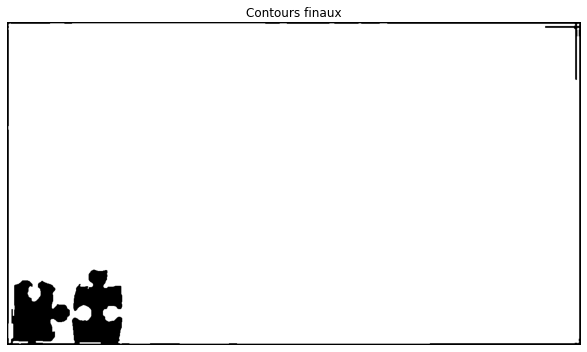

In [496]:
image = cv2.imread('puzzle.jpg', cv2.IMREAD_COLOR)

# changement de l'image en hsv pour segmenter le fond orange
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
orange_lower = np.array([10, 100, 100])
orange_upper = np.array([25, 255, 255])
mask_orange = cv2.inRange(hsv, orange_lower, orange_upper)
mask_pieces = cv2.bitwise_not(mask_orange)

cv2.imwrite("DEBUG_mask_pieces.png", mask_pieces)


# traitement basé sur le masque

# on applique un flou pour réduire le bruit
fltr_img = cv2.medianBlur(mask_pieces, 5)

# on améliore le contraste:
alpha = 1.5  
beta = 0    
image_contraste = cv2.convertScaleAbs(fltr_img, alpha=alpha, beta=beta)

# Binarisation
resultat = cv2.adaptiveThreshold(
    image_contraste, 255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 11, 2
)

# Morphologie : 

matrice_kernel = np.ones((3,3), np.uint8)
resultat = cv2.morphologyEx(resultat, cv2.MORPH_CLOSE, matrice_kernel)

matrice_kernel = np.ones((2,2),np.uint8)
resultat_dilatation = cv2.dilate(resultat, matrice_kernel, iterations=1)

matrice_kernel = np.ones((2,2), np.uint8)
resultat_erosion = cv2.erode(resultat_dilatation, matrice_kernel, iterations=2) 

resultat_erosion = resultat

# Détection et dessin des contours
# Ici, nous utilisons la variable "fermeture" qui contient l'image traitée
contours, _ = cv2.findContours(resultat_erosion, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = np.zeros_like(mask_pieces, dtype=np.uint8)
cv2.drawContours(contour_img, contours, -1, 255, thickness=cv2.FILLED)
print(f"Nombre de pièces détectées : {len(contours)}")


image_contours = image.copy()
cv2.drawContours(image_contours, contours, -1, (0, 255, 0), 2)
cv2.imwrite("DEBUG_contours_sur_image.png", image_contours)



# Affichage
plt.figure(figsize=(10, 5))

plt.imshow(contour_img, cmap='gray')
#plt.savefig("puzzle_binarise.png")
plt.title("Contours finaux")
plt.axis('off')


#les graphs suivants m'ont permis de mieux visualiser les images
#plt.subplot(141)
#plt.imshow(mask_pieces, cmap='gray')
#plt.title("Masque des pièces (hors orange)")
#plt.axis('off')

#plt.subplot(142)
#plt.imshow(resultat_erosion, cmap='gray')
#plt.title("Après traitement morphologique")
#plt.axis('off')



plt.tight_layout()
plt.show()


#on a essayé de convertir l'image en image hsv pour enlever le fond orange et garder les pièces mais ça resulte avec seulement 2 pièces qui apparaissent

Nombre de contours detectés: 30


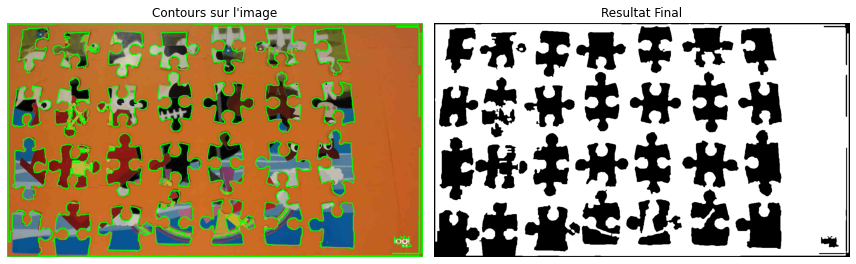

In [498]:
#donc on a essayé de le faire d'une autre methode:

matrice_kernel = np.ones((3, 3), np.uint8)
fermeture = cv2.morphologyEx(fltr_img, cv2.MORPH_CLOSE, matrice_kernel, iterations=5)

retour, image_binaire = cv2.threshold(fermeture, 127, 255, cv2.THRESH_BINARY)


# contours
contours, _ = cv2.findContours(image_binaire, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"Nombre de contours detectés: {len(contours)}")


# on dessine les contours 
final_img = np.full_like(image_binaire, 255)
cv2.drawContours(final_img, filtered_contours, -1, 0, thickness=cv2.FILLED)

# on montre les contours sur l'original pour debugger
contour_debug = orig.copy()
cv2.drawContours(contour_debug, filtered_contours, -1, (0, 255, 0), 2)
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(contour_debug, cv2.COLOR_BGR2RGB))
plt.title("Contours sur l'image")
plt.axis('off')

plt.subplot(122)
plt.imshow(final_img, cmap='gray')
plt.title("Resultat Final")
plt.axis('off')
plt.savefig("puzzle_binarise.png")

plt.tight_layout()
plt.show()

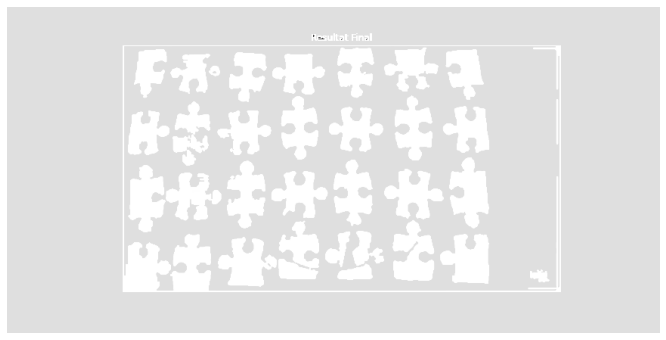

In [490]:
#on a donc gardé le deuxieme resultat pour la suite et enregistré l'image sous le nom "puzzle_binarise"


puzzle_mask = cv2.imread('puzzle_binarise.png', cv2.IMREAD_GRAYSCALE)

inversion_noir_blanc = cv2.bitwise_not(puzzle_mask)

puzzle_rgb = cv2.cvtColor(inversion_noir_blanc, cv2.COLOR_GRAY2RGB)

nombre_pieces, labels, status, centroids = cv2.connectedComponentsWithStats(puzzle_mask, connectivity=8)

nombre_lignes = max(centroids[:, 1])

nuances_gris = 255 / nombre_lignes

for label in range(1, nombre_pieces):
    puzzle_piece = np.where(labels == label, 255, 0).astype(np.uint8)
    
    centroid = centroids[label]
    nombre_ligne = int(centroid[1]) 
    
    intensite = int(nombre_ligne * nuances_gris)
    
    puzzle_rgb[:, :, 0] = np.clip(puzzle_rgb[:, :, 0].astype(np.int32) + (puzzle_piece / 255) * intensite, 0, 255).astype(np.uint8)
    puzzle_rgb[:, :, 1] = np.clip(puzzle_rgb[:, :, 1].astype(np.int32) + (puzzle_piece / 255) * intensite, 0, 255).astype(np.uint8)
    puzzle_rgb[:, :, 2] = np.clip(puzzle_rgb[:, :, 2].astype(np.int32) + (puzzle_piece / 255) * intensite, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.imshow(puzzle_rgb)
plt.axis('off')
plt.show()


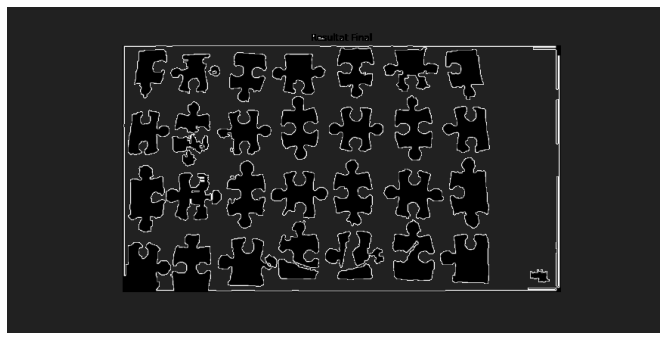

In [492]:
##Pieces sur fond noir en nuances de gris mais les pieces ont un contour blanc..

puzzle_mask = cv2.imread('puzzle_binarise.png', cv2.IMREAD_GRAYSCALE)

inversion_noir_blanc = cv2.bitwise_not(puzzle_mask)

puzzle_rgb = cv2.cvtColor(puzzle_mask, cv2.COLOR_GRAY2RGB)


puzzle_rgb[np.all(puzzle_rgb == [255, 255, 255], axis=-1)] = [0, 0, 0]

nombre_pieces, labels, status, centroids = cv2.connectedComponentsWithStats(puzzle_mask, connectivity=8)

nombre_lignes = max(centroids[:, 1])

nuances_gris = 255 / nombre_lignes

for label in range(1, nombre_pieces):
    puzzle_piece = np.where(labels == label, 255, 0).astype(np.uint8)
    
    centroid = centroids[label]
    nombre_ligne = int(centroid[1]) 
    
    intensite = int(nombre_ligne * nuances_gris)
    
    puzzle_rgb[:, :, 0] = np.clip(puzzle_rgb[:, :, 0].astype(np.int32) + (puzzle_piece ) * intensite, 0, 255).astype(np.uint8)
    puzzle_rgb[:, :, 1] = np.clip(puzzle_rgb[:, :, 1].astype(np.int32) + (puzzle_piece ) * intensite, 0, 255).astype(np.uint8)
    puzzle_rgb[:, :, 2] = np.clip(puzzle_rgb[:, :, 2].astype(np.int32) + (puzzle_piece ) * intensite, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.imshow(puzzle_rgb)
plt.axis('off')
plt.show()